In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## SECTION 1: Load Dataset

In [21]:
import pandas as pd # Added for robustness

try:
    df = pd.read_csv('/content/drive/MyDrive/mobi_data2_processed.csv')

    # Display shape
    print(f"Dataset Shape: {df.shape}")

    # Display data types
    print("\nData Types:")
    display(df.info())

    # Display feature list
    print("\nFeature List:")
    display(df.columns.tolist())

except FileNotFoundError:
    print("Error: 'mobi_data2_processed.csv' not found. Please ensure the file is in '/content/drive/MyDrive/' or update the file path.")
    raise FileNotFoundError("Required data file 'mobi_data2_processed.csv' not found. Please place it in the specified Google Drive path.")

Dataset Shape: (999999, 56)

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 56 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   occurred_on                      999999 non-null  object 
 1   alarm_id                         999999 non-null  int64  
 2   location_information             999999 non-null  object 
 3   additional_information           999999 non-null  object 
 4   received_on                      999999 non-null  object 
 5   enodeb_id                        999999 non-null  object 
 6   gnodeb_id                        999999 non-null  object 
 7   alarm_type_encoded               999999 non-null  int64  
 8   severity_encoded                 999999 non-null  int64  
 9   occurred_on_hour                 999999 non-null  int64  
 10  occurred_on_day                  999999 non-null  int64  
 11  occurred_on_weekday     

None


Feature List:


['occurred_on',
 'alarm_id',
 'location_information',
 'additional_information',
 'received_on',
 'enodeb_id',
 'gnodeb_id',
 'alarm_type_encoded',
 'severity_encoded',
 'occurred_on_hour',
 'occurred_on_day',
 'occurred_on_weekday',
 'occurred_on_month',
 'mo_name_encoded',
 'alarm_name_encoded',
 'alarm_duration_minutes',
 'alarm_source_encoded',
 'maintenance_status_encoded',
 'ne_type_encoded',
 'object_type_encoded',
 'received_on_hour',
 'received_on_day',
 'received_on_weekday',
 'received_on_month',
 'subnet_encoded',
 'type_encoded',
 'previous_alarm_1',
 'previous_alarm_2',
 'previous_alarm_3',
 'previous_alarm_4',
 'previous_alarm_5',
 'previous_severity_1',
 'previous_severity_2',
 'previous_severity_3',
 'previous_severity_4',
 'previous_severity_5',
 'previous_alarm_source_1',
 'previous_alarm_source_2',
 'previous_alarm_source_3',
 'previous_alarm_source_4',
 'previous_alarm_source_5',
 'previous_object_type_1',
 'previous_object_type_2',
 'previous_object_type_3',
 'pre

Section 2 — Candidate Feature Removal

In [26]:
# Columns that are candidates for removal
candidate_remove = [
    'ne_type_encoded',
    'object_type_encoded',
    'subnet_encoded',
    'type_encoded',
    'alarm_source_encoded'
]

print("Candidate features for removal:")
for col in candidate_remove:
    print(f"- {col}")

Candidate features for removal:
- ne_type_encoded
- object_type_encoded
- subnet_encoded
- type_encoded
- alarm_source_encoded


In [27]:
target = 'target'

candidate_analysis = (
    df[candidate_remove + [target]]
    .groupby(candidate_remove)
    .size()
)

print(candidate_analysis.head())

ne_type_encoded  object_type_encoded  subnet_encoded  type_encoded  alarm_source_encoded
0                43                   3               11            68                         7
1                0                    28              3             1842                    1008
                                                                    2360                    1142
                                                                    2844                    2248
                                                                    3517                    2499
dtype: int64


In [28]:
columns_to_remove = [
    'ne_type_encoded',
    'object_type_encoded',
    'subnet_encoded',
    'type_encoded',
    'alarm_source_encoded'
]

df = df.drop(columns=columns_to_remove)

print("Removed columns:")
print(columns_to_remove)

print("\nNew dataset shape:", df.shape)

Removed columns:
['ne_type_encoded', 'object_type_encoded', 'subnet_encoded', 'type_encoded', 'alarm_source_encoded']

New dataset shape: (999999, 51)


## SECTION 4: Correlation Analysis

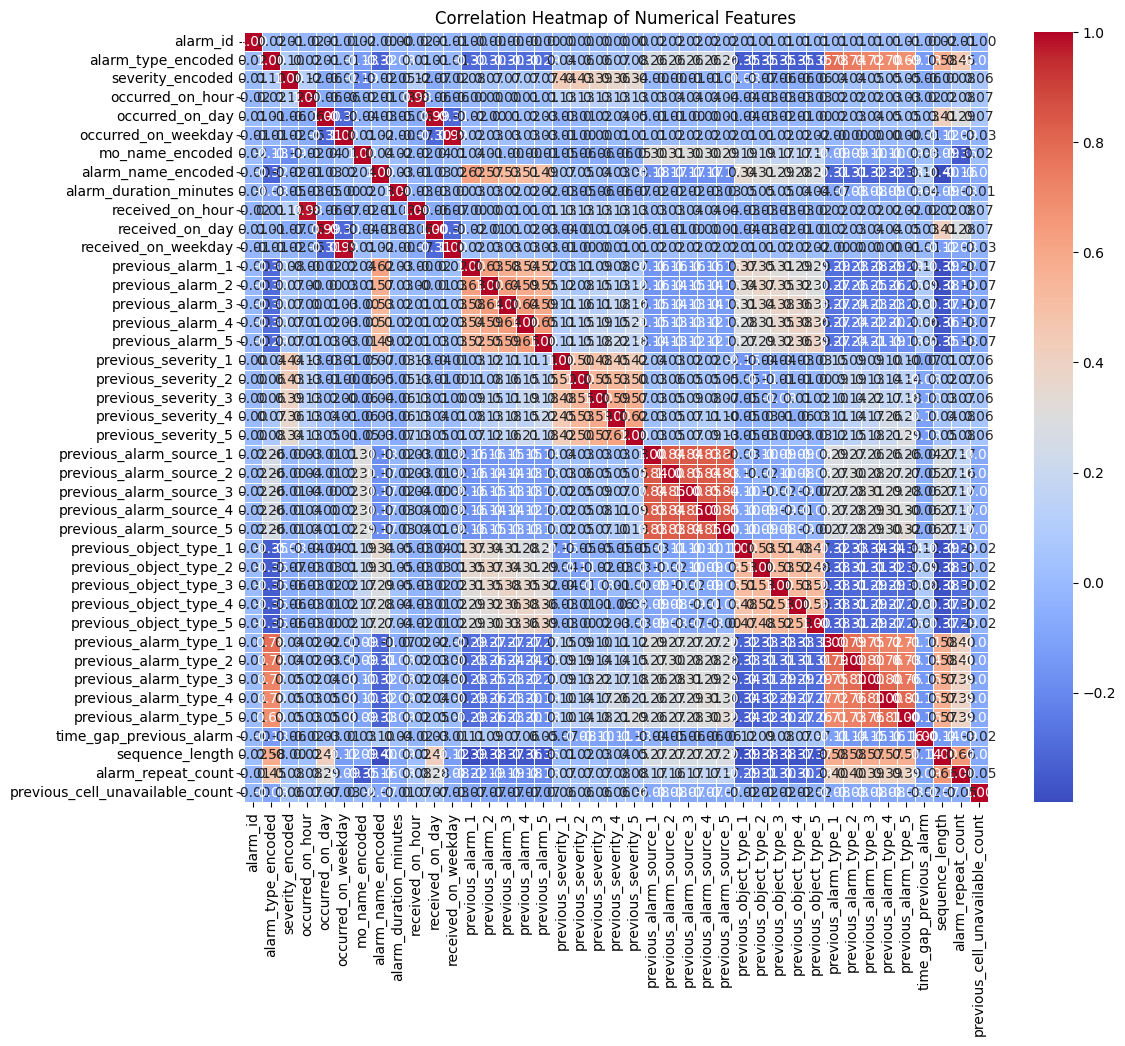


Highly Correlated Numerical Features (to each other, threshold > 0.8):


['received_on_hour',
 'previous_alarm_source_4',
 'received_on_day',
 'previous_alarm_source_5',
 'previous_alarm_type_5',
 'previous_alarm_source_3',
 'previous_alarm_type_4',
 'received_on_weekday',
 'previous_alarm_source_2']


No highly correlated features found above the threshold (0.8).


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical features for correlation analysis
X_numeric = X_vt_selected.select_dtypes(include=np.number)

# Calculate Pearson correlation matrix
corr_matrix = X_numeric.corr()

# Generate a correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Identify highly correlated numerical features (e.g., correlation > 0.8 or < -0.8)
high_corr_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8: # Adjust threshold as needed
            colname = corr_matrix.columns[i]
            high_corr_features.add(colname)

print("\nHighly Correlated Numerical Features (to each other, threshold > 0.8):")
display(list(high_corr_features))

features_to_remove_corr = []
if features_to_remove_corr:
    print("\nSuggested features to remove due to high correlation:")
    display(features_to_remove_corr)
else:
    print("\nNo highly correlated features found above the threshold (0.8).")

## SECTION 5: Mutual Information

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Mutual Information (MI) scores
# MI measures the dependency between the target variable and each feature.
# It can capture non-linear relationships and works for both numerical and categorical features.

# Encode categorical features for MI calculation (mutual_info_classif requires numerical input)
X_mi = X_vt_selected.copy()
for col in X_mi.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_mi[col] = le.fit_transform(X_mi[col])

# Calculate MI scores
mi_scores = mutual_info_classif(X_mi, y, random_state=42)

# Create a DataFrame for better visualization and ranking
mi_df = pd.DataFrame({'Feature': X_mi.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

print("Top 20 Features by Mutual Information Score:")
display(mi_df.head(20))

# Visualize using a horizontal bar chart for the top 20 features
plt.figure(figsize=(12, 8))
sns.barplot(x='MI_Score', y='Feature', data=mi_df.head(20), palette='viridis')
plt.title('Top 20 Features by Mutual Information Score')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()